In [ ]:
pip install PyPDF2

In [10]:
# Install all necessary libraries for the Streamlit application
!pip install streamlit scikit-learn pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.9 MB/s eta 0:00:00


In [ ]:
import PyPDF2

pdf_path = '/content/student ai project.pdf'

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text() or ""
    except Exception as e:
        text = f"Error reading PDF: {e}"
    return text

pdf_content = extract_text_from_pdf(pdf_path)

print("--- Extracted PDF Content (first 1000 characters) ---")
print(pdf_content[:1000])
print("\n--- End of preview ---")


### **1. Generate Synthetic Dataset**

As described in Section 5 of the PDF, a synthetic dataset of 500 student records will be generated with the specified features and target variable. This step uses `numpy` to create realistic-looking data for `Hours_Study`, `Attendance`, `Previous_Marks`, `Assignments_Done`, and `Sleep_Hours`. The `Result` (Pass/Fail) is then determined based on a realistic marks formula.

In [1]:
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

# Number of synthetic student records
num_students = 500

# Generate synthetic data for features based on ranges described in the PDF
hours_study = np.random.randint(1, 13, num_students)  # 1 to 12 hours
attendance = np.random.randint(40, 101, num_students) # 40 to 100%
previous_marks = np.random.randint(30, 101, num_students) # 30 to 100
assignments_done = np.random.randint(0, 11, num_students) # 0 to 10
sleep_hours = np.random.randint(4, 11, num_students) # 4 to 10 hours

# Create a 'realistic' formula for marks to simulate Pass/Fail
# This formula aims to create a distribution where higher feature values lead to higher marks
# and consequently, a higher chance of passing.
simulated_marks = (
    (hours_study * 5) +
    (attendance * 0.5) +
    (previous_marks * 0.7) +
    (assignments_done * 4) +
    (sleep_hours * 2)
)

# Normalize simulated_marks to be within a reasonable range, e.g., 0-100
simulated_marks = np.interp(simulated_marks, (simulated_marks.min(), simulated_marks.max()), (30, 100))

# Determine Result: 0 = Fail (marks < 50), 1 = Pass (marks >= 50)
result = (simulated_marks >= 50).astype(int)

# Create DataFrame
data = {
    'Hours_Study': hours_study,
    'Attendance': attendance,
    'Previous_Marks': previous_marks,
    'Assignments_Done': assignments_done,
    'Sleep_Hours': sleep_hours,
    'Result': result # Target variable
}
df = pd.DataFrame(data)

print("Synthetic dataset generated successfully. Displaying first 5 rows:")
display(df.head())
print("\nDistribution of Result (Pass/Fail):")
display(df['Result'].value_counts())


Synthetic dataset generated successfully. Displaying first 5 rows:


,Hours_Study,Attendance,Previous_Marks,Assignments_Done,Sleep_Hours,Result
0,7,69,90,7,8,1
1,4,85,80,9,4,1
2,11,91,48,6,10,1
3,8,44,50,6,6,1
4,5,51,34,6,9,0



Distribution of Result (Pass/Fail):


,count
Result,
1,412
0,88


### **2. Data Preprocessing (Feature Scaling and Train-Test Split)**

As per Section 8 of the PDF, the data will be split into an 80% training set and 20% testing set. Features will be scaled using `StandardScaler` to ensure that all features contribute equally to the model training, which is crucial for Logistic Regression.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df[['Hours_Study', 'Attendance', 'Previous_Marks', 'Assignments_Done', 'Sleep_Hours']]
y = df['Result']

# Split data into training and testing sets (80/20 split as per PDF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and fit StandardScaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Data split and scaled successfully.
X_train_scaled shape: (400, 5)
X_test_scaled shape: (100, 5)


### **3. Model Training (Logistic Regression)**

The model chosen for this project is Logistic Regression, as stated in Section 8. We will train the model using the scaled training data and the specified configuration (`max_iter=1000`, `random_state=42`).

In [3]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with specified parameters
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### **4. Model Evaluation**

To assess the model's performance, we will evaluate it using standard metrics mentioned in Section 9 of the PDF: Accuracy, Precision, Recall, and F1 Score, along with a Confusion Matrix.

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


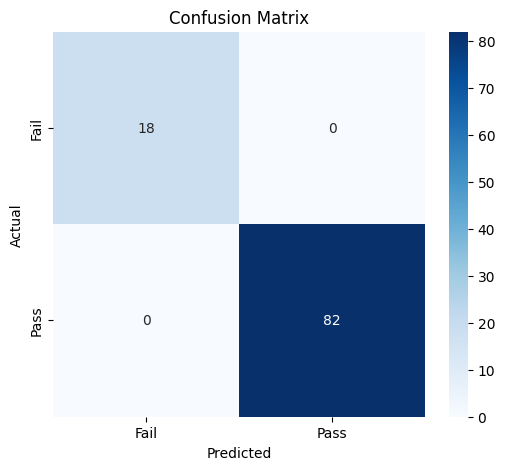

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### **5. Demonstrate a Prediction**

This section demonstrates how to use the trained model to make a prediction for a new, unseen student, including calculating the confidence score, as shown in Section 10 of the PDF ('Prediction with Confidence').

In [5]:
# Example input for a new student
# Values should be within the ranges used for synthetic data generation
# Hours_Study (1-12), Attendance (40-100), Previous_Marks (30-100),
# Assignments_Done (0-10), Sleep_Hours (4-10)

new_student_data = {
    'Hours_Study': 9,
    'Attendance': 85,
    'Previous_Marks': 75,
    'Assignments_Done': 8,
    'Sleep_Hours': 7
}

# Convert to DataFrame for consistent scaling
new_student_df = pd.DataFrame([new_student_data])

# Scale the new student's data using the *same scaler* fitted on the training data
new_student_scaled = scaler.transform(new_student_df)

# Make a prediction (0 for Fail, 1 for Pass)
prediction = model.predict(new_student_scaled)[0]

# Get prediction probabilities (e.g., [prob_fail, prob_pass])
probabilities = model.predict_proba(new_student_scaled)[0]

predicted_outcome = 'Pass' if prediction == 1 else 'Fail'
confidence = probabilities[prediction] * 100

print("\n--- New Student Prediction ---")
print(f"Input Data: {new_student_data}")
print(f"Predicted Outcome: {predicted_outcome}")
print(f"Confidence: {confidence:.2f}%")



--- New Student Prediction ---
Input Data: {'Hours_Study': 9, 'Attendance': 85, 'Previous_Marks': 75, 'Assignments_Done': 8, 'Sleep_Hours': 7}
Predicted Outcome: Pass
Confidence: 100.00%


### **7. Feature Importance Analysis**

Although Logistic Regression doesn't have a direct 'feature importance' attribute like tree-based models, we can infer feature importance from the absolute values of its coefficients. A larger absolute coefficient value indicates a stronger influence of that feature on the target variable. This corresponds to the 'Feature Importance bar chart' mentioned in Section 7 (Tab 3).

Feature Coefficients and Importance:


,Feature,Coefficient,Abs_Coefficient
0,Hours_Study,3.364193,3.364193
2,Previous_Marks,2.878252,2.878252
3,Assignments_Done,2.542628,2.542628
1,Attendance,1.594359,1.594359
4,Sleep_Hours,0.634349,0.634349


/tmp/ipykernel_945/2621998126.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance, palette='viridis')


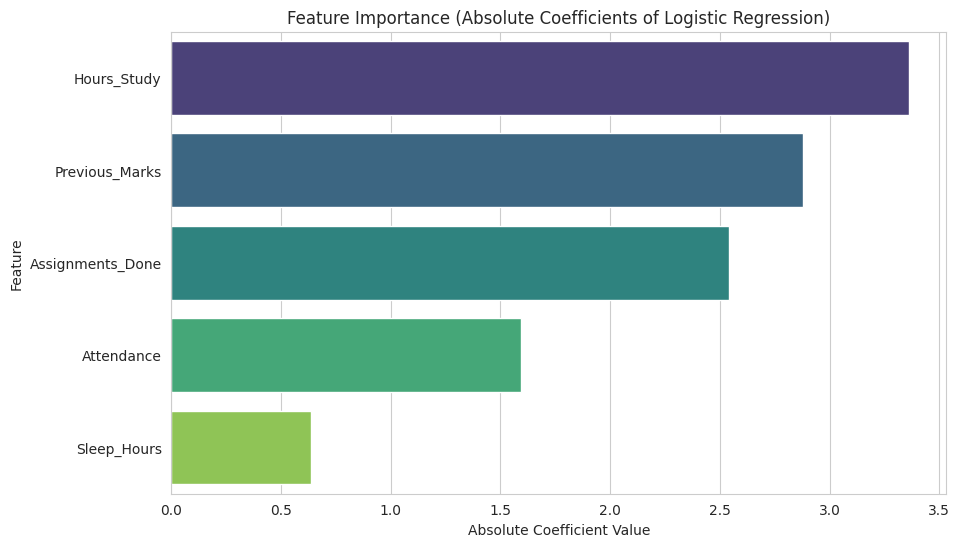

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names from the original DataFrame
feature_names = X.columns

# Get the coefficients from the trained Logistic Regression model
coefficients = model.coef_[0]

# Create a DataFrame for coefficients and their absolute values
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value to see most important features
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Feature Coefficients and Importance:")
display(feature_importance)

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients of Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()


### **8. Streamlit Web Application (Projectt.py)**

This section generates the Python code for the Streamlit web application, combining all the components (model prediction, data analysis, and model performance) into an interactive UI as described in Sections 7 and 11 of the PDF. You can save this code as `Projectt.py` and run it locally.

**Note**: To run this code, you will need to install Streamlit along with other libraries:
`pip install streamlit scikit-learn pandas numpy matplotlib seaborn`

2026-06-26 04:41:20.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 04:41:20.638 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 04:41:20.660 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 04:41:21.005 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-26 04:41:21.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 04:41:21.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 04:41:21.008 Thread 'MainThread'

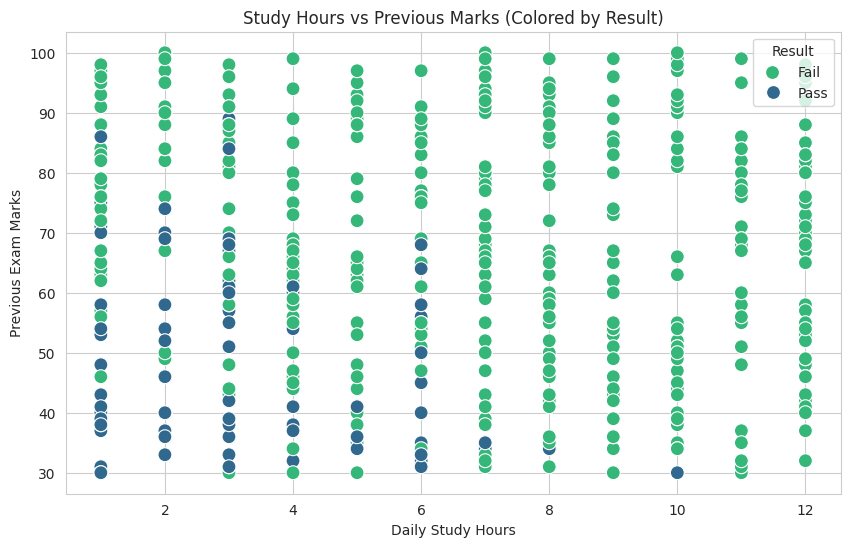

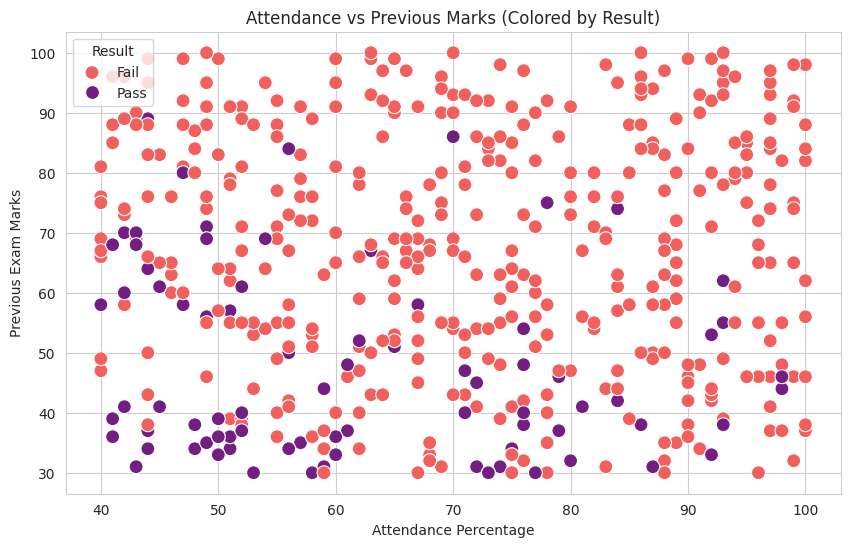

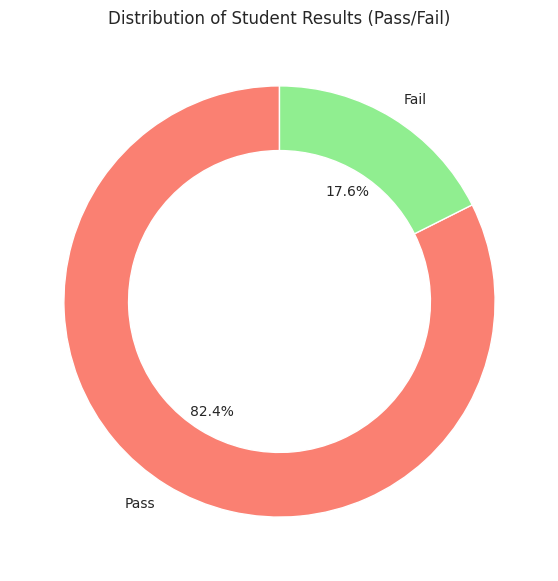

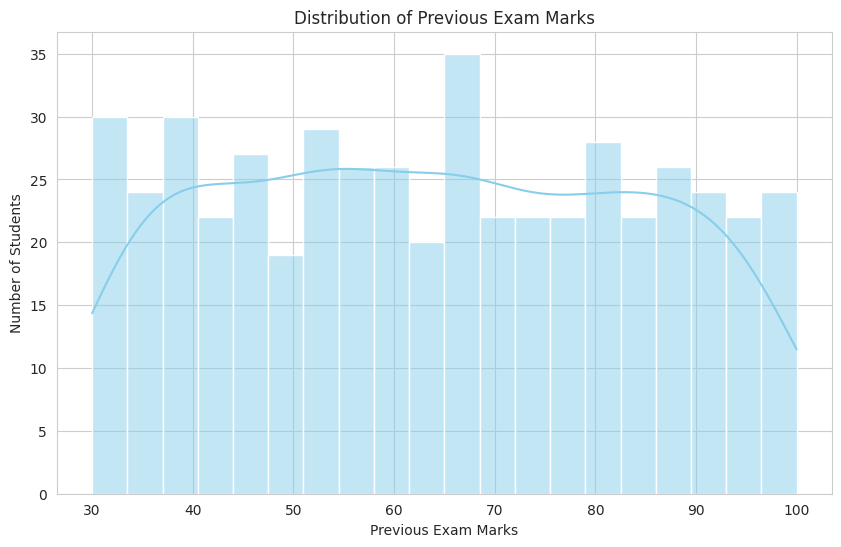

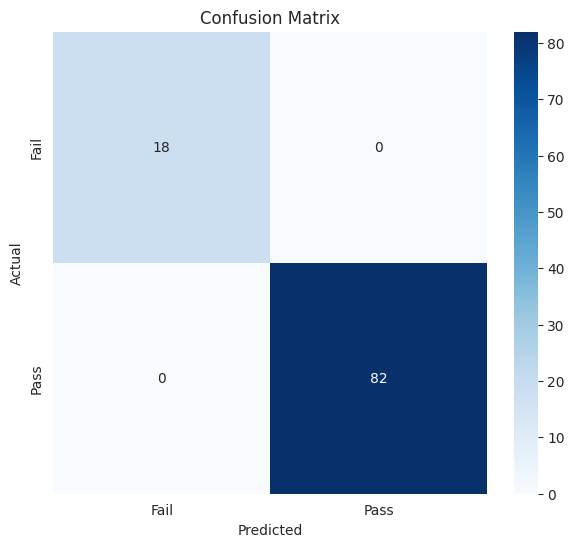

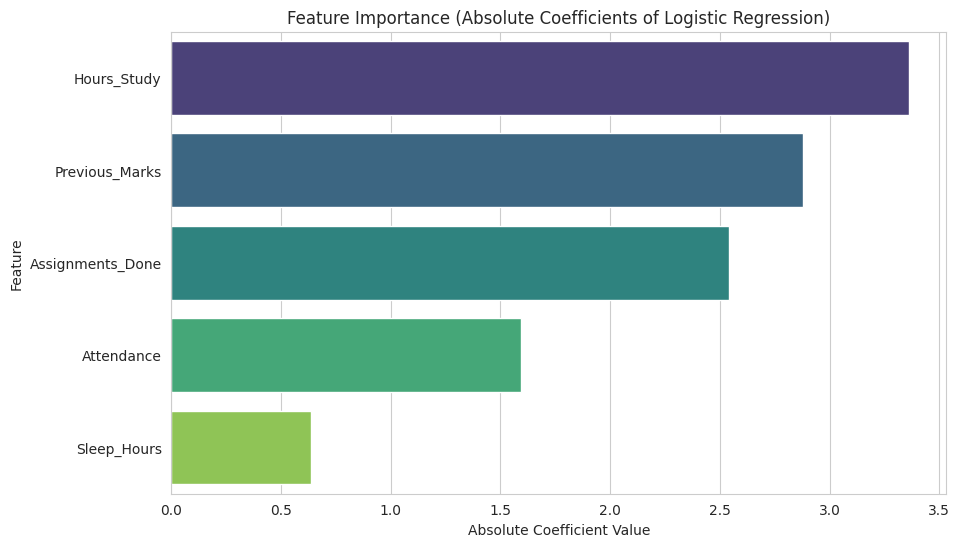

In [11]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(layout="wide", page_title="Student Result Prediction System")

# --- 1. Data Generation and Model Training (as in previous cells) ---
@st.cache_resource # Cache the data generation and model training for efficiency
def load_model_and_data():
    np.random.seed(42)
    num_students = 500

    hours_study = np.random.randint(1, 13, num_students)
    attendance = np.random.randint(40, 101, num_students)
    previous_marks = np.random.randint(30, 101, num_students)
    assignments_done = np.random.randint(0, 11, num_students)
    sleep_hours = np.random.randint(4, 11, num_students)

    simulated_marks = (
        (hours_study * 5) +
        (attendance * 0.5) +
        (previous_marks * 0.7) +
        (assignments_done * 4) +
        (sleep_hours * 2)
    )
    simulated_marks = np.interp(simulated_marks, (simulated_marks.min(), simulated_marks.max()), (30, 100))
    result = (simulated_marks >= 50).astype(int)

    data = {
        'Hours_Study': hours_study,
        'Attendance': attendance,
        'Previous_Marks': previous_marks,
        'Assignments_Done': assignments_done,
        'Sleep_Hours': sleep_hours,
        'Result': result
    }
    df = pd.DataFrame(data)

    X = df[['Hours_Study', 'Attendance', 'Previous_Marks', 'Assignments_Done', 'Sleep_Hours']]
    y = df['Result']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)

    return df, X, y, X_test, y_test, model, scaler

df, X, y, X_test, y_test, model, scaler = load_model_and_data()

# --- Streamlit UI ---
st.title("Student Result Prediction System")
st.markdown("A Machine Learning web application to predict student pass/fail results.")

tab1, tab2, tab3 = st.tabs(["Predict Result", "Data Analysis", "Model Performance"])

with tab1:
    st.header("Predict Student Result")
    st.markdown("Enter the student's academic and lifestyle parameters to get a prediction.")

    col1, col2, col3 = st.columns(3)

    with col1:
        hours_study = st.slider("Daily Study Hours (1-12)", 1, 12, 5)
        attendance = st.slider("Attendance Percentage (40-100%)", 40, 100, 75)

    with col2:
        previous_marks = st.slider("Previous Exam Marks (30-100)", 30, 100, 60)
        assignments_done = st.slider("Assignments Completed (0-10)", 0, 10, 5)

    with col3:
        sleep_hours = st.slider("Average Daily Sleep Hours (4-10)", 4, 10, 7)

    input_data = pd.DataFrame([[hours_study, attendance, previous_marks, assignments_done, sleep_hours]],
                              columns=X.columns)

    if st.button("Predict Result"):
        scaled_input = scaler.transform(input_data)
        prediction = model.predict(scaled_input)[0]
        probabilities = model.predict_proba(scaled_input)[0]

        predicted_outcome = 'PASS' if prediction == 1 else 'FAIL'
        confidence = probabilities[prediction] * 100

        if predicted_outcome == 'PASS':
            st.success(f"Predicted Result: **{predicted_outcome}**")
        else:
            st.error(f"Predicted Result: **{predicted_outcome}**")
        st.info(f"Confidence: **{confidence:.2f}%**")

        st.subheader("Input Summary")
        st.table(input_data)

with tab2:
    st.header("Data Analysis")
    st.markdown("Visualizations and summary statistics of the synthetic student dataset.")

    st.subheader("Summary Statistics")
    total_students = len(df)
    pass_count = df['Result'].sum()
    fail_count = total_students - pass_count
    pass_rate = (pass_count / total_students) * 100

    metrics_col1, metrics_col2, metrics_col3 = st.columns(3)
    metrics_col1.metric("Total Students", total_students)
    metrics_col2.metric("Pass Rate", f"{pass_rate:.2f}%")
    metrics_col3.metric("Fail Count", fail_count)

    st.subheader("Visualizations")

    # Study Hours vs Marks
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x='Hours_Study', y='Previous_Marks', hue='Result', data=df, palette='viridis', s=100, ax=ax1)
    ax1.set_title('Study Hours vs Previous Marks (Colored by Result)')
    ax1.set_xlabel('Daily Study Hours')
    ax1.set_ylabel('Previous Exam Marks')
    ax1.legend(title='Result', labels=['Fail', 'Pass'])
    st.pyplot(fig1)

    # Attendance vs Marks
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x='Attendance', y='Previous_Marks', hue='Result', data=df, palette='magma', s=100, ax=ax2)
    ax2.set_title('Attendance vs Previous Marks (Colored by Result)')
    ax2.set_xlabel('Attendance Percentage')
    ax2.set_ylabel('Previous Exam Marks')
    ax2.legend(title='Result', labels=['Fail', 'Pass'])
    st.pyplot(fig2)

    # Pass/Fail Pie Chart
    fig3, ax3 = plt.subplots(figsize=(7, 7))
    df['Result'].map({0: 'Fail', 1: 'Pass'}).value_counts().plot.pie(
        autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightgreen'],
        wedgeprops=dict(width=0.3), ax=ax3
    )
    ax3.set_title('Distribution of Student Results (Pass/Fail)')
    ax3.set_ylabel('')
    st.pyplot(fig3)

    # Marks Distribution Histogram
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    sns.histplot(df['Previous_Marks'], bins=20, kde=True, color='skyblue', ax=ax4)
    ax4.set_title('Distribution of Previous Exam Marks')
    ax4.set_xlabel('Previous Exam Marks')
    ax4.set_ylabel('Number of Students')
    st.pyplot(fig4)

with tab3:
    st.header("Model Performance")
    st.markdown("Key metrics and visualizations to assess the Logistic Regression model's effectiveness.")

    y_pred = model.predict(scaler.transform(X_test))

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    st.subheader("Evaluation Metrics")
    col_metrics1, col_metrics2, col_metrics3, col_metrics4 = st.columns(4)
    col_metrics1.metric("Accuracy", f"{accuracy:.4f}")
    col_metrics2.metric("Precision", f"{precision:.4f}")
    col_metrics3.metric("Recall", f"{recall:.4f}")
    col_metrics4.metric("F1 Score", f"{f1:.4f}")

    st.markdown(
        "_**Accuracy:** Percentage of students correctly classified (Pass or Fail)._\n"
        "_**Precision:** Of all students predicted as PASS, how many actually passed?_\n"
        "_**Recall:** Of all students who actually passed, how many were correctly identified?_\n"
        "_**F1 Score:** Harmonic mean of Precision and Recall, balancing both metrics._"
    )

    st.subheader("Confusion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=ax_cm)
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_title('Confusion Matrix')
    st.pyplot(fig_cm)

    st.subheader("Feature Importance")
    feature_names = X.columns
    coefficients = model.coef_[0]
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    })
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

    fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_df, palette='viridis', ax=ax_fi)
    ax_fi.set_title('Feature Importance (Absolute Coefficients of Logistic Regression)')
    ax_fi.set_xlabel('Absolute Coefficient Value')
    ax_fi.set_ylabel('Feature')
    st.pyplot(fig_fi)


### **6. Data Analysis and Visualizations**

As per Section 7 (Tab 2) of the PDF, this section will generate various plots to visualize the dataset characteristics and relationships between features and the target variable. This includes scatter plots, a pie chart, and a histogram.

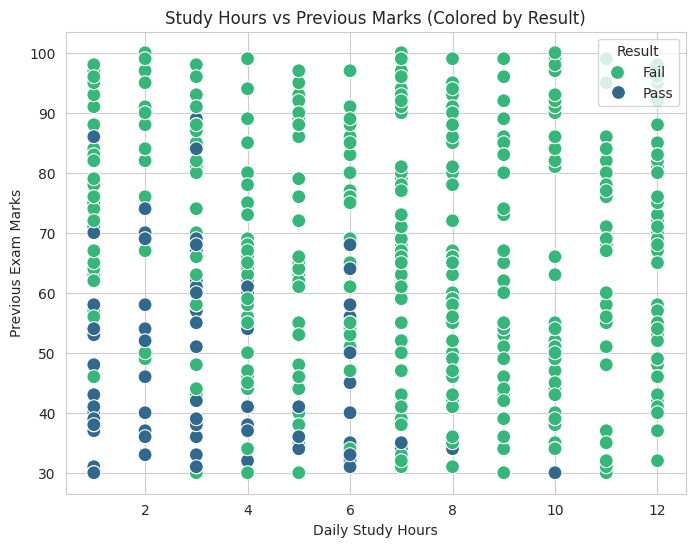

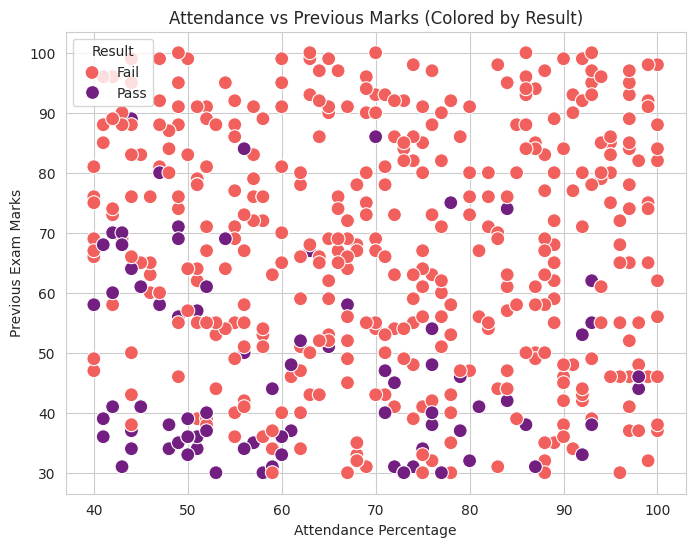

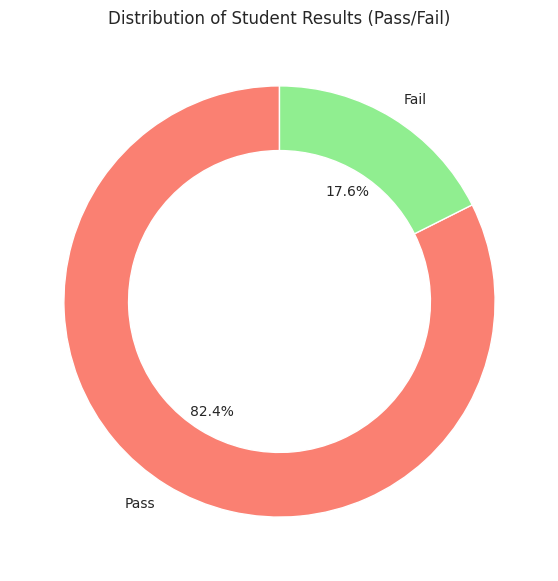

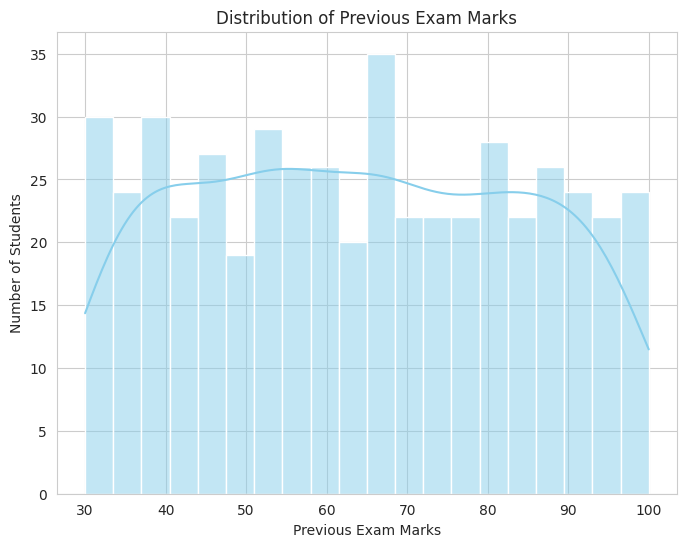


--- Summary Statistics ---
Total Students: 500
Pass Count: 412
Fail Count: 88
Pass Rate: 82.40%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. Study Hours vs Marks (scatter plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours_Study', y='Previous_Marks', hue='Result', data=df, palette='viridis', s=100)
plt.title('Study Hours vs Previous Marks (Colored by Result)')
plt.xlabel('Daily Study Hours')
plt.ylabel('Previous Exam Marks')
plt.legend(title='Result', labels=['Fail', 'Pass'])
plt.show()

# 2. Attendance vs Marks (scatter plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Attendance', y='Previous_Marks', hue='Result', data=df, palette='magma', s=100)
plt.title('Attendance vs Previous Marks (Colored by Result)')
plt.xlabel('Attendance Percentage')
plt.ylabel('Previous Exam Marks')
plt.legend(title='Result', labels=['Fail', 'Pass'])
plt.show()

# 3. Pass/Fail pie chart
plt.figure(figsize=(7, 7))
df['Result'].map({0: 'Fail', 1: 'Pass'}).value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightgreen'],
    wedgeprops=dict(width=0.3)
)
plt.title('Distribution of Student Results (Pass/Fail)')
plt.ylabel('') # Hide the default 'Result' label
plt.show()

# 4. Marks distribution histogram (using Previous_Marks as a proxy for overall 'marks')
plt.figure(figsize=(8, 6))
sns.histplot(df['Previous_Marks'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Previous Exam Marks')
plt.xlabel('Previous Exam Marks')
plt.ylabel('Number of Students')
plt.show()

# Also show summary statistics (total students, pass count, fail count, pass rate)
print("\n--- Summary Statistics ---")
total_students = len(df)
pass_count = df['Result'].sum()
fail_count = total_students - pass_count
pass_rate = (pass_count / total_students) * 100

print(f"Total Students: {total_students}")
print(f"Pass Count: {pass_count}")
print(f"Fail Count: {fail_count}")
print(f"Pass Rate: {pass_rate:.2f}%")


Now that the text from the PDF has been extracted, for student result prediction, we typically need a structured dataset. This dataset would usually contain features like student demographics, previous academic performance, attendance, study hours, etc., along with their final results.

Please describe what kind of information is contained in the PDF regarding student results and other relevant data. For example:

*   **Is the data structured** (e.g., tables of grades, student IDs, features)?
*   **What specific variables** should be used for prediction?
*   **What is the target variable** (i.e., what are we trying to predict, e.g., pass/fail, a specific grade, a score)?

Once I understand the structure and content of the data within this PDF, I can help you with the next steps to prepare the data and build a prediction model.